In [1]:
import numpy as np

In [2]:

def R(v):
    X,Y,Z = v
    return X, X*Y - Z, Y

def L(v):
    X,Y,Z = v
    return  Y*X - Z, Y, X

class Triple():
    def __init__(self, 
                 nums=(3,3,3),
                 basis=np.array([[1,0],[0,1]])):
        self.nums = nums
        self.vecs = basis
        
    def R(self):
        X,Y,Z = self.nums
        V = self.vecs
        return Triple(nums=(X, X*Y - Z, Y), 
                      basis=np.dot(np.array([[1,1],[1,0]]),V)
                     )
        
    def L(self):
        X,Y,Z = self.nums
        V = self.vecs
        return Triple(nums=(Y*X - Z, Y, X), 
                      basis=np.dot(np.array([[1,0],[1,1]]),V) 
                     )
    
    def __repr__(self):
        return str(self.nums)

    
class Triple():
    def __init__(self, 
                 nums=(3,3,3),
                 basis=( np.array([1,0]), np.array([0,1]))
                ):
        self.nums = nums
        self.vecs = basis
        
    def R(self):
        X,Y,Z = self.nums
        V = self.vecs
        return Triple(nums=(X, X*Y - Z, Y), 
                      basis=(V[0], V[0]+V[1])
                     )
        
    def L(self):
        X,Y,Z = self.nums
        V = self.vecs
        return Triple(nums=(Y*X - Z, Y, X), 
                      basis=(V[0]+V[1], V[1]) 
                     )
    
    def __repr__(self):
        return str(self.nums)


class IterTree(object):
    #this is a list of lists one at each depth in the tree
    def __init__(self, max_size=1000):
        self.max = max_size
        self.triples = [ ]
    
    def make(self,v,d=0):
        
        self.triples.append(v)
        d +=1
        if d > 5: return
        if max(v.nums) < self.max and min(v.nums) > -self.max:
            self.make(v.L(),d=d)
            self.make(v.R(), d=d)
        return
    

In [3]:
import numpy as np

basis = ( np.array([1,0]), np.array([0,1]) )

root = Triple(nums=(2,4,0),basis=basis)
mark = IterTree(max_size= 5000)
mark.make(root)

# The different types of generator

$\text{tr} X = 0 \Rightarrow X$ is an element of order 2
and the Dehn twist (Nielsen transformation) 
https://en.wikipedia.org/wiki/Nielsen_transformation

$(x,y,z) \mapsto ( xy - z, y, x)$

is order 4 so we get a cycle in the Markoff numbers:

$(4, 0, 2) \rightarrow (-2, 0, 4) \rightarrow  (-4, 0, -2) \rightarrow (2, 0, -4) \rightarrow  (4, 0, 2)$

$\text{tr} X = 0 \Rightarrow X$ is a parabolic element 
and the Dehn twist (?? move) is infinite order and 
we get an arithemetic progression:

$4, 2, 0)\rightarrow (8, 2, 4)\rightarrow (12, 2, 8)\rightarrow (16, 2, 12)\rightarrow (20, 2, 16)\rightarrow (24, 2, 20) \ldots$


So to count the integer points in this orbit we should count the integer points
inside a wedge which is a fundamental domain in $\mathbb{R}^2$
for the action of the action of the Dehn twist round the "curve which is order 4"


In [4]:
nums = []

nn = plot_fig(0,4,2)

NameError: name 'plot_fig' is not defined

in the figure the Dehn twist along the order 4 element 
corresponds to a transvection $(x,y) \mapsto (x, x+y)$
so we see an infinite band appearing.

In [15]:
mark.triples

[(2, 4, 0),
 (8, 4, 2),
 (30, 4, 8),
 (112, 4, 30),
 (418, 4, 112),
 (1560, 4, 418),
 (418, 1560, 4),
 (112, 418, 4),
 (46812, 418, 112),
 (112, 46812, 418),
 (30, 112, 4),
 (3356, 112, 30),
 (375842, 112, 3356),
 (3356, 375842, 112),
 (30, 3356, 112),
 (100568, 3356, 30),
 (30, 100568, 3356),
 (8, 30, 4),
 (236, 30, 8),
 (7072, 30, 236),
 (236, 7072, 30),
 (8, 236, 30),
 (1858, 236, 8),
 (438480, 236, 1858),
 (1858, 438480, 236),
 (8, 1858, 236),
 (14628, 1858, 8),
 (8, 14628, 1858),
 (2, 8, 4),
 (12, 8, 2),
 (94, 8, 12),
 (740, 8, 94),
 (5826, 8, 740),
 (740, 5826, 8),
 (94, 740, 8),
 (69552, 740, 94),
 (94, 69552, 740),
 (12, 94, 8),
 (1120, 94, 12),
 (105268, 94, 1120),
 (1120, 105268, 94),
 (12, 1120, 94),
 (13346, 1120, 12),
 (12, 13346, 1120),
 (2, 12, 8),
 (16, 12, 2),
 (190, 12, 16),
 (2264, 12, 190),
 (190, 2264, 12),
 (16, 190, 12),
 (3028, 190, 16),
 (16, 3028, 190),
 (2, 16, 12),
 (20, 16, 2),
 (318, 16, 20),
 (20, 318, 16),
 (2, 20, 16),
 (24, 20, 2),
 (2, 24, 20)]

In [17]:
import matplotlib.pyplot as plt

/home/gregmcshane/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in true_divide
  """
/home/gregmcshane/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in true_divide
  """


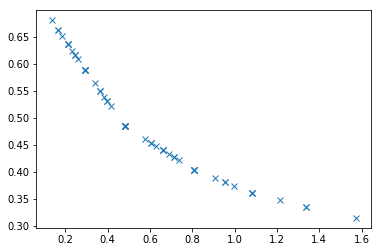

In [18]:
def ff(x):
    x = abs(x)
    return np.log( .5*(x + np.sqrt(x**2 - 4)))

uu = [ t.vecs[0]/ff(t.nums[0]) for t in mark.triples]
X, Y = zip(* uu)   
plt.plot(X,Y, 'x')

In [45]:
root = Triple(nums=(2.1,2.01,-2.01),basis=basis)
mark = IterTree(max_size= 5000)
mark.make(root)

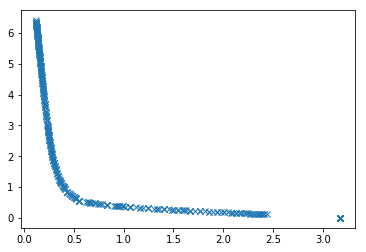

In [46]:
uu = [ t.vecs[0]/ff(t.nums[0]) for t in mark.triples]
X, Y = zip(* uu)   
plt.plot(X,Y, 'x')

In [22]:
class Markoff(object):
    
    def __init__(self, mn = (3,np.array([1,0]))):
        self.n, self.v = mn
    
    #this is cheating as it breaks the symetry 
    #between + and - 
    #but the subsequent code looks better
    
    def __mul__(self, other):
        return Markoff((self.n*other.n, self.v + other.v))
    
    def __sub__(self, other):
        return Markoff((self.n - other.n, self.v))
    
    def __abs__(self):
        return abs(self.n)
    
    def m2v(self):
        #thisis a dumb name for a function
        length = acosh(self.n)
        #not elegant I want to check if  .real exists
        if not isinstance(length, np.float64):
            length = abs(length.real)
   
        return self.v/length
        
    def __str__(self):
        return str(self.n)
    
    def __repr__(self):
        return repr(self.n)

In [23]:
def acosh(u):
    #this will take complex numbers
    if abs(u**2 - 4) < .000001: return 10**3
    return np.log( .5*(u + np.sqrt(u**2 - 4)))

In [30]:
# these two are global to tree()
max_depth = 10000
nums = []
# but who cares?

def tree(mt, dd):
    global nums
    dd +=1
    x,y,z = mt
    nums.append(z)
    if abs(z) > max_depth or dd > 20:
        return
    tree((z,y,y*z - x), dd)
    tree((x,z,x*z - y), dd)


In [34]:
nums  = []

def plot_fig(a=3,b=3,c=3):
    
    x = Markoff((a, np.array([1,0]) ))
    y = Markoff((b, np.array([0,1]) ))
    z = Markoff((c, np.array([1,1]) ))
    
    tree((x,y,z), dd=0)
    x = Markoff((a, np.array([-1,0]) ))
    z = Markoff((a*b-c, np.array([-1,1]) ))
    tree((x,y,z), dd=0)
    
    TT = [ n.m2v() for n in nums]
    TT = [v for v in TT if np.linalg.norm(v) < 20]
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)
    ax.set_aspect(2) 
    ax.axis('off')
    XS, YS = zip(*TT)
    ax.plot(XS,YS,'r.')
    TT = [ -v for v in TT]
    XS, YS = zip(* TT)
    ax.plot(XS,YS,'b.')

    XS,YS = [0,0], [-2,2]
    ax.plot(XS,YS,'k')
    ax.plot(YS,XS,'k')
    return nums

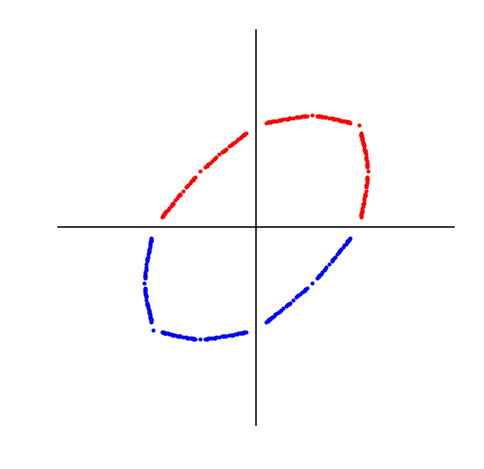

In [25]:
nn = plot_fig(3,3,3)

/home/gregmcshane/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in log
  after removing the cwd from sys.path.


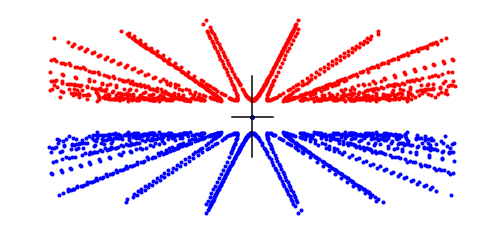

In [35]:
nums = []

nn = plot_fig(0,4,2)